# **Implementación en R (Pipeline Completo)**

Desde la exploración visual básica hasta el modelado exploratorio con modelr

In [ ]:
# %%R
if (!require("pacman")) install.packages("pacman")

Loading required package: pacman

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘pacman’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘remotes’




In [ ]:
require(pacman)
pacman::p_load(tidyverse,modelr)

In [ ]:
View(p_load)

function (..., char, install = TRUE, update = getOption("pac_update"), 
    character.only = FALSE) 
{
    if (!missing(char)) {
        packages <- char
    }
    else if (character.only) {
        packages <- eval(match.call()[[2]])
    }
    else {
        packages <- as.character(match.call(expand.dots = FALSE)[[2]])
    }
    if (length(packages) == 0) {
        return(invisible())
    }
    if (is.null(update)) {
        update <- FALSE
    }
    if (update) {
        p_update()
    }
    loaded <- sapply(packages, p_load_single, install = install)
    if (!all(loaded)) {
        failed <- packages[!loaded]
        warning("Failed to install/load:\n", paste(failed, collapse = ", "))
    }
    return(invisible(loaded))
}
<bytecode: 0x57892d147990>
<environment: namespace:pacman>

In [ ]:
# 1. Datos simulados de la industria
set.seed(42)
df_maquinas <- tibble(
  velocidad = runif(100, 1000, 3000),
  proveedor = sample(c("A", "B"), 100, replace = TRUE),
  # El Proveedor A tiene un bonus oculto de +200h de vida
  vida_util = 5000 - (velocidad * 1.2) + ifelse(proveedor == "A", 200, 0) + rnorm(100, 0, 50)
)

In [ ]:
df_maquinas

velocidad,proveedor,vida_util
<dbl>,<chr>,<dbl>
2829.612,B,1664.514
2874.151,B,1603.257
1572.279,A,3263.105
2660.895,B,1899.350
2283.491,A,2426.472
2038.192,B,2559.445
2473.177,B,2011.075
1269.333,A,3670.683
2313.985,B,2232.628


In [ ]:
# 2. Fase Tukey: EDA Bivariado Visual
plot_tukey <- ggplot(df_maquinas, aes(x = velocidad, y = vida_util)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = FALSE, color = "darkgray") +
  labs(title = "EDA Bivariado (La Señal)") + theme_bw()

`geom_smooth()` using formula = 'y ~ x'


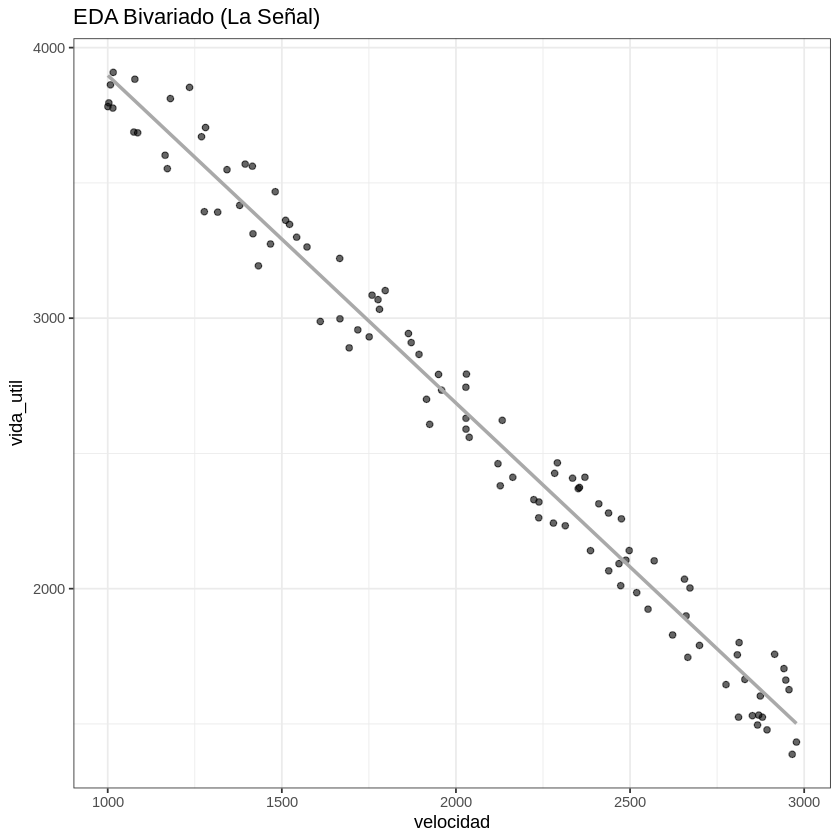

In [ ]:
plot_tukey

In [ ]:
# 3. Fase Wickham: Modelado Exploratorio
modelo = lm(vida_util ~ velocidad, data = df_maquinas)

df_maquinas_exp = df_maquinas |>
  add_predictions(modelo) |>
  add_residuals(modelo)

In [ ]:
df_maquinas_exp

velocidad,proveedor,vida_util,pred,resid
<dbl>,<chr>,<dbl>,<dbl>,<dbl>
2829.612,B,1664.514,1680.998,-16.48401
2874.151,B,1603.257,1627.032,-23.77591
1572.279,A,3263.105,3204.444,58.66111
2660.895,B,1899.350,1885.423,13.92650
2283.491,A,2426.472,2342.705,83.76750
2038.192,B,2559.445,2639.921,-80.47553
2473.177,B,2011.075,2112.872,-101.79705
1269.333,A,3670.683,3571.508,99.17514
2313.985,B,2232.628,2305.757,-73.12897


In [ ]:
summary(modelo)


Call:
lm(formula = vida_util ~ velocidad, data = df_maquinas)

Residuals:
    Min      1Q  Median      3Q     Max 
-180.06  -96.54  -21.64  101.52  239.99 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 5109.49331   39.73471  128.59   <2e-16 ***
velocidad     -1.21165    0.01861  -65.11   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 111.8 on 98 degrees of freedom
Multiple R-squared:  0.9774,	Adjusted R-squared:  0.9772 
F-statistic:  4239 on 1 and 98 DF,  p-value: < 2.2e-16


In [ ]:
# 4. Revelando el EDA Multivariado a través de Residuos
plot_wickham <- ggplot(df_maquinas_exp, aes(x = proveedor, y = resid, fill = proveedor)) +
  geom_boxplot() +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Análisis de Residuos: Descubrimiento Multivariado")


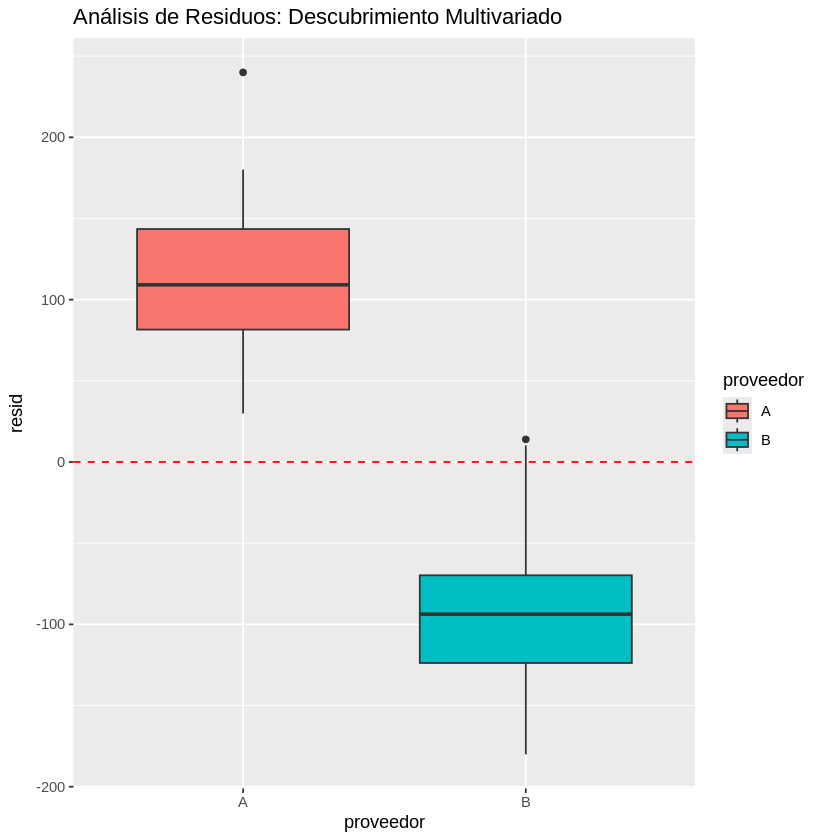

In [ ]:
plot_wickham

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


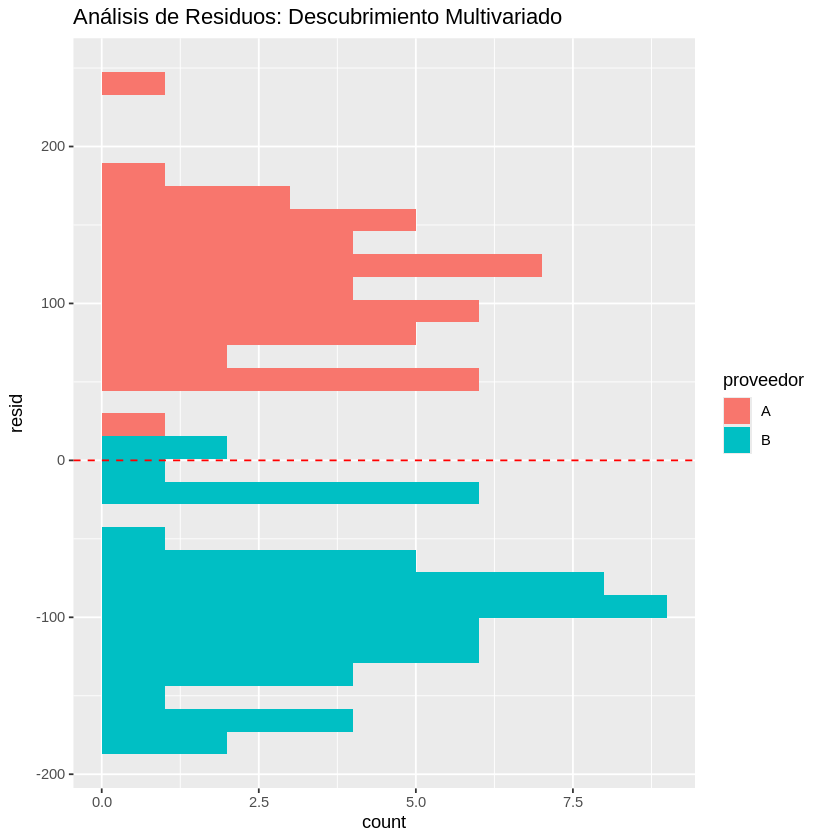

In [ ]:
# 4. Revelando el EDA Multivariado a través de Residuos
plot_wickham <- ggplot(df_maquinas_exp, aes(y = resid, fill = proveedor)) +
  geom_histogram() +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Análisis de Residuos: Descubrimiento Multivariado")

plot_wickham

In [ ]:
# 3. Fase Wickham: Modelado Exploratorio
modelo2 = lm(vida_util ~ velocidad + proveedor, data = df_maquinas)

df_maquinas_exp = df_maquinas |>
  add_predictions(modelo2) |>
  add_residuals(modelo2)

In [ ]:
summary(modelo2)


Call:
lm(formula = vida_util ~ velocidad + proveedor, data = df_maquinas)

Residuals:
    Min      1Q  Median      3Q     Max 
-93.747 -26.212   0.534  26.778 135.889 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  5.202e+03  1.673e+01  310.85   <2e-16 ***
velocidad   -1.202e+00  7.605e-03 -158.05   <2e-16 ***
proveedorB  -2.037e+02  9.185e+00  -22.18   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 45.62 on 97 degrees of freedom
Multiple R-squared:  0.9963,	Adjusted R-squared:  0.9962 
F-statistic: 1.298e+04 on 2 and 97 DF,  p-value: < 2.2e-16
